In [2]:
# ============================================================
# PROJECT 1: Myntra MarketWatch — Unveiling E-commerce Trends
# Dataset: Fashion Dataset v2.csv (Real Myntra Data)
# Tools: Python, Pandas, Matplotlib, Seaborn, EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings

warnings.filterwarnings('ignore')

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


In [3]:
# Load YOUR dataset
df = pd.read_csv("Fashion Dataset v2.csv")

print("✅ Dataset Loaded!")
print(f"📦 Shape: {df.shape}")
print(f"\n📋 Columns: {df.columns.tolist()}")
df.head(3)

✅ Dataset Loaded!
📦 Shape: (14214, 11)

📋 Columns: ['p_id', 'name', 'products', 'price', 'colour', 'brand', 'img', 'ratingCount', 'avg_rating', 'description', 'p_attributes']


,p_id,name,products,price,colour,brand,img,ratingCount,avg_rating,description,p_attributes
0,17048614,Khushal K Women Black Ethnic Motifs Printed Ku...,"Kurta, Palazzos, Dupatta",5099.0,Black,Khushal K,http://assets.myntassets.com/assets/images/170...,4522.0,4.418399,Black printed Kurta with Palazzos with dupatta...,"{'Add-Ons': 'NA', 'Body Shape ID': '443,333,32..."
1,16524740,InWeave Women Orange Solid Kurta with Palazzos...,"Kurta, Palazzos, Floral Print Dupatta",5899.0,Orange,InWeave,http://assets.myntassets.com/assets/images/165...,1081.0,4.119334,Orange solid Kurta with Palazzos with dupatta<...,"{'Add-Ons': 'NA', 'Body Shape ID': '443,333,32..."
2,16331376,Anubhutee Women Navy Blue Ethnic Motifs Embroi...,"Kurta, Trousers, Dupatta",4899.0,Navy Blue,Anubhutee,http://assets.myntassets.com/assets/images/163...,1752.0,4.161530,Navy blue embroidered Kurta with Trousers with...,"{'Add-Ons': 'NA', 'Body Shape ID': '333,424', ..."


In [4]:
# -----------------------------------------------
# STEP 1: UNDERSTAND THE DATA
# -----------------------------------------------
print("=" * 50)
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"\nTotal Products   : {df.shape[0]}")
print(f"Total Columns    : {df.shape[1]}")
print(f"\n🔍 Data Types:\n{df.dtypes}")
print(f"\n❓ Missing Values:\n{df.isnull().sum()}")
print(f"\n🔁 Duplicate Rows: {df.duplicated().sum()}")

📊 DATASET OVERVIEW

Total Products   : 14214
Total Columns    : 11

🔍 Data Types:
p_id              int64
name             object
products         object
price           float64
colour           object
brand            object
img              object
ratingCount     float64
avg_rating      float64
description      object
p_attributes     object
dtype: object

❓ Missing Values:
p_id               0
name               0
products           0
price              0
colour             0
brand              0
img                0
ratingCount     7684
avg_rating      7684
description        0
p_attributes       0
dtype: int64

🔁 Duplicate Rows: 0


In [5]:
# -----------------------------------------------
# STEP 2: CLEAN THE DATA
# -----------------------------------------------

# Drop duplicates
df.drop_duplicates(inplace=True)

# Drop rows where price is missing
df.dropna(subset=['price'], inplace=True)

# Fill missing ratingCount and avg_rating with 0
df['ratingCount'] = df['ratingCount'].fillna(0)
df['avg_rating']  = df['avg_rating'].fillna(0)

# Fix data types
df['price']       = pd.to_numeric(df['price'], errors='coerce')
df['ratingCount'] = pd.to_numeric(df['ratingCount'], errors='coerce')
df['avg_rating']  = pd.to_numeric(df['avg_rating'], errors='coerce')

# Drop rows with invalid price
df.dropna(subset=['price'], inplace=True)

# Clean colour column - strip whitespace
df['colour'] = df['colour'].str.strip()

# Clean brand column - strip whitespace
df['brand'] = df['brand'].str.strip()

# -----------------------------------------------
# FEATURE ENGINEERING: Add New Columns
# -----------------------------------------------

# 1) Price Segment
def price_segment(price):
    if price < 1000:
        return 'Budget (< ₹1K)'
    elif price < 2500:
        return 'Mid-Range (₹1K–2.5K)'
    elif price < 5000:
        return 'Premium (₹2.5K–5K)'
    else:
        return 'Luxury (> ₹5K)'

df['Price_Segment'] = df['price'].apply(price_segment)

# 2) Rating Category
def rate_category(r):
    if r == 0:
        return 'No Rating'
    elif r < 3.5:
        return 'Low (< 3.5)'
    elif r < 4.0:
        return 'Average (3.5–4.0)'
    elif r < 4.5:
        return 'Good (4.0–4.5)'
    else:
        return 'Excellent (≥ 4.5)'

df['Rating_Category'] = df['avg_rating'].apply(rate_category)

# 3) Has Dupatta
df['Has_Dupatta'] = df['products'].str.contains('Dupatta', case=False, na=False)

# 4) Product Type (first item in products)
df['Product_Type'] = df['products'].str.split(',').str[0].str.strip()

print("✅ Cleaning Done!")
print(f"Final Shape: {df.shape}")
df[['name','brand','price','colour','avg_rating','ratingCount',
    'Price_Segment','Rating_Category']].head()

✅ Cleaning Done!
Final Shape: (14214, 15)


,name,brand,price,colour,avg_rating,ratingCount,Price_Segment,Rating_Category
0,Khushal K Women Black Ethnic Motifs Printed Ku...,Khushal K,5099.0,Black,4.418399,4522.0,Luxury (> ₹5K),Good (4.0–4.5)
1,InWeave Women Orange Solid Kurta with Palazzos...,InWeave,5899.0,Orange,4.119334,1081.0,Luxury (> ₹5K),Good (4.0–4.5)
2,Anubhutee Women Navy Blue Ethnic Motifs Embroi...,Anubhutee,4899.0,Navy Blue,4.161530,1752.0,Premium (₹2.5K–5K),Good (4.0–4.5)
3,Nayo Women Red Floral Printed Kurta With Trous...,Nayo,3699.0,Red,4.088986,4113.0,Premium (₹2.5K–5K),Good (4.0–4.5)
4,AHIKA Women Black & Green Printed Straight Kurta,AHIKA,1350.0,Black,3.978377,21274.0,Mid-Range (₹1K–2.5K),Average (3.5–4.0)


In [6]:
# -----------------------------------------------
# STEP 3: BASIC STATISTICS
# -----------------------------------------------

print("=" * 55)
print("       📊 MYNTRA MARKETWATCH — KEY STATS")
print("=" * 55)

rated = df[df['avg_rating'] > 0]

print(f"\n  🛍️  Total Products      : {len(df):,}")
print(f"  🏪  Unique Brands       : {df['brand'].nunique():,}")
print(f"  🎨  Unique Colours      : {df['colour'].nunique():,}")
print(f"  💰  Avg Price           : ₹{df['price'].mean():.0f}")
print(f"  💰  Median Price        : ₹{df['price'].median():.0f}")
print(f"  💰  Price Range         : ₹{df['price'].min():.0f}  –  ₹{df['price'].max():.0f}")
print(f"  ⭐  Avg Rating          : {rated['avg_rating'].mean():.2f} / 5")
print(f"  👥  Avg Rating Count    : {rated['ratingCount'].mean():.0f}")
print(f"  🧣  Products w/ Dupatta : {df['Has_Dupatta'].sum():,}")

print("=" * 55)

       📊 MYNTRA MARKETWATCH — KEY STATS

  🛍️  Total Products      : 14,214
  🏪  Unique Brands       : 1,022
  🎨  Unique Colours      : 50
  💰  Avg Price           : ₹2970
  💰  Median Price        : ₹2222
  💰  Price Range         : ₹169  –  ₹47999
  ⭐  Avg Rating          : 4.10 / 5
  👥  Avg Rating Count    : 184
  🧣  Products w/ Dupatta : 1,932


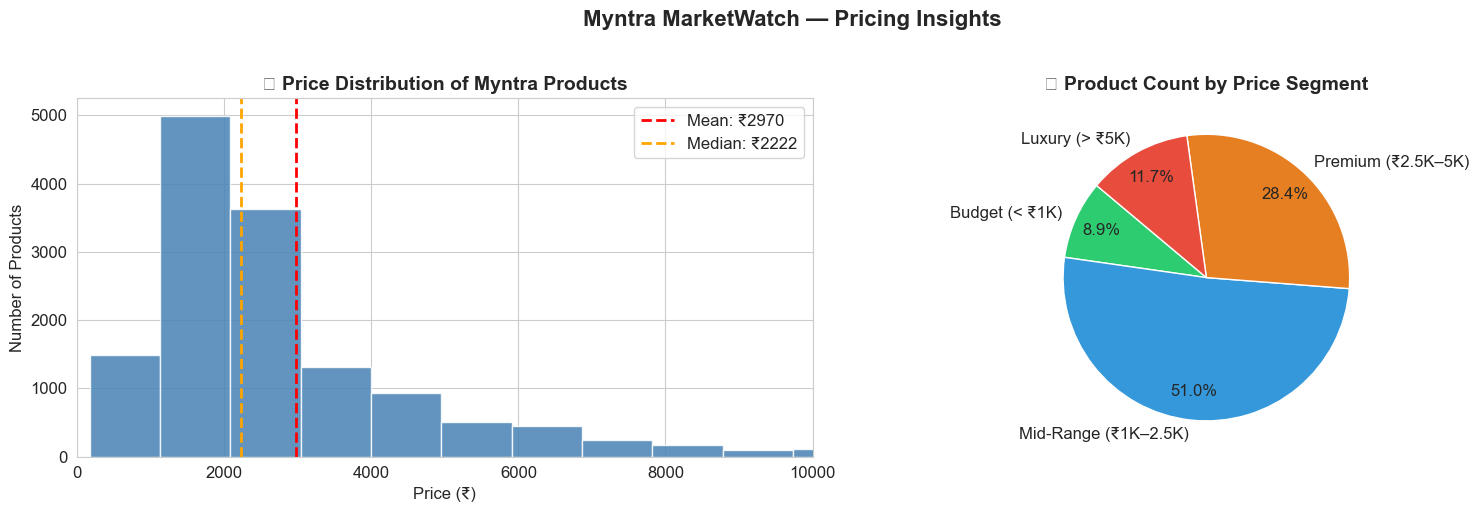

📌 Insight: Most Myntra products are Mid-Range (₹1K–₹2.5K). The distribution is right-skewed — very few luxury items.


In [7]:
# -----------------------------------------------
# CHART 1: Price Distribution (Histogram + KDE)
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(df['price'], bins=50, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(df['price'].mean(),   color='red',
                linestyle='--', linewidth=2,
                label=f"Mean: ₹{df['price'].mean():.0f}")
axes[0].axvline(df['price'].median(), color='orange',
                linestyle='--', linewidth=2,
                label=f"Median: ₹{df['price'].median():.0f}")
axes[0].set_title("💰 Price Distribution of Myntra Products",
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel("Price (₹)")
axes[0].set_ylabel("Number of Products")
axes[0].set_xlim(0, 10000)
axes[0].legend()

# Price Segment Pie
segment_order = ['Budget (< ₹1K)', 'Mid-Range (₹1K–2.5K)',
                 'Premium (₹2.5K–5K)', 'Luxury (> ₹5K)']
seg_counts = df['Price_Segment'].value_counts().reindex(segment_order)
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
axes[1].pie(seg_counts.values, labels=seg_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.80)
axes[1].set_title("📦 Product Count by Price Segment",
                  fontsize=14, fontweight='bold')

plt.suptitle("Myntra MarketWatch — Pricing Insights",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("chart1_price_distribution.png", dpi=150,
            bbox_inches='tight')
plt.show()

print("📌 Insight: Most Myntra products are Mid-Range (₹1K–₹2.5K).",
      "The distribution is right-skewed — very few luxury items.")

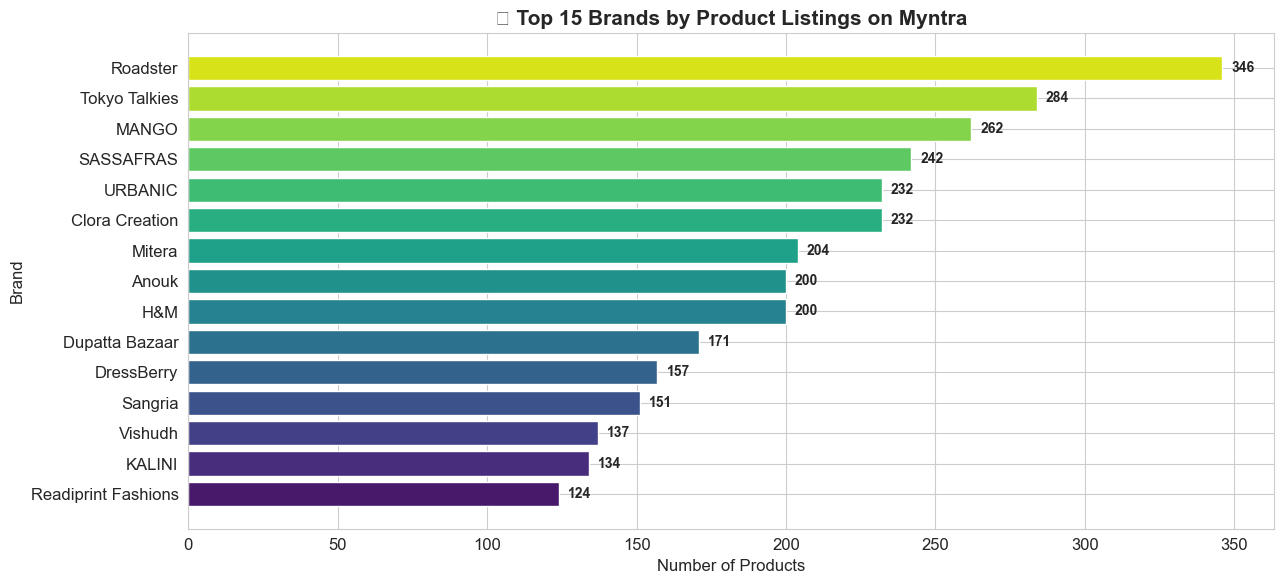

📌 Insight: 'Roadster' leads with the most listings (346 products) on Myntra — indicating highest brand presence in ethnic women's wear.


In [8]:
# -----------------------------------------------
# CHART 2: Top 15 Brands by Number of Listings
# -----------------------------------------------

top_brands = df['brand'].value_counts().head(15)

plt.figure(figsize=(13, 6))
bars = plt.barh(top_brands.index[::-1],
                top_brands.values[::-1],
                color=sns.color_palette("viridis", 15))
plt.title("🏆 Top 15 Brands by Product Listings on Myntra",
          fontsize=15, fontweight='bold')
plt.xlabel("Number of Products", fontsize=12)
plt.ylabel("Brand", fontsize=12)

for i, (val, bar) in enumerate(zip(top_brands.values[::-1], bars)):
    plt.text(val + 3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("chart2_top_brands.png", dpi=150)
plt.show()

print(f"📌 Insight: '{top_brands.index[0]}' leads with the most",
      f"listings ({top_brands.values[0]} products) on Myntra —",
      "indicating highest brand presence in ethnic women's wear.")

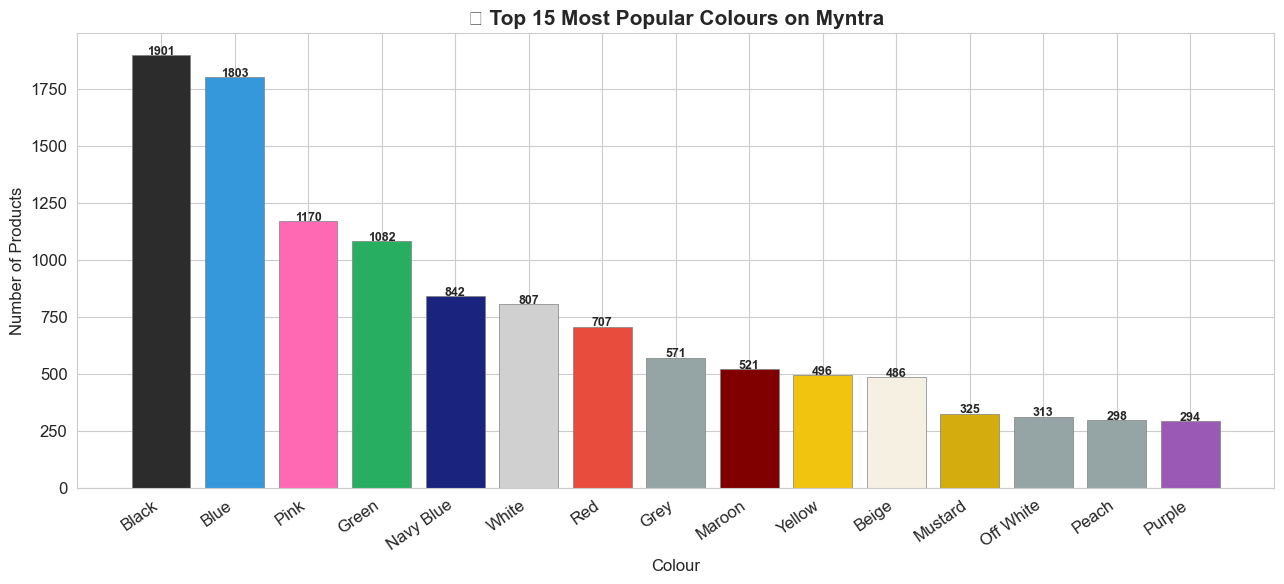

📌 Insight: 'Black' dominates Myntra's ethnic wear catalogue — reflecting Indian fashion preferences and festive occasion dressing.


In [9]:
# -----------------------------------------------
# CHART 3: Top 15 Most Popular Colours
# -----------------------------------------------

top_colours = df['colour'].value_counts().head(15)

# Map colours to approximate hex values for visual
colour_map = {
    'Black': '#2c2c2c', 'White': '#d0d0d0', 'Blue': '#3498db',
    'Pink': '#ff69b4',  'Red': '#e74c3c',   'Green': '#27ae60',
    'Yellow': '#f1c40f','Navy Blue': '#1a237e','Purple': '#9b59b6',
    'Maroon': '#800000','Teal': '#008080',   'Beige': '#f5f0e1',
    'Orange': '#e67e22','Mustard': '#d4ac0d','Lavender': '#b39ddb'
}

bar_colors = [colour_map.get(c, '#95a5a6') for c in top_colours.index]

plt.figure(figsize=(13, 6))
bars = plt.bar(top_colours.index, top_colours.values,
               color=bar_colors, edgecolor='grey', linewidth=0.5)
plt.title("🎨 Top 15 Most Popular Colours on Myntra",
          fontsize=15, fontweight='bold')
plt.xlabel("Colour", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)
plt.xticks(rotation=35, ha='right')

for bar, val in zip(bars, top_colours.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2, str(val),
             ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig("chart3_colour_trends.png", dpi=150)
plt.show()

top_col = top_colours.index[0]
print(f"📌 Insight: '{top_col}' dominates Myntra's ethnic wear catalogue —",
      "reflecting Indian fashion preferences and festive occasion dressing.")

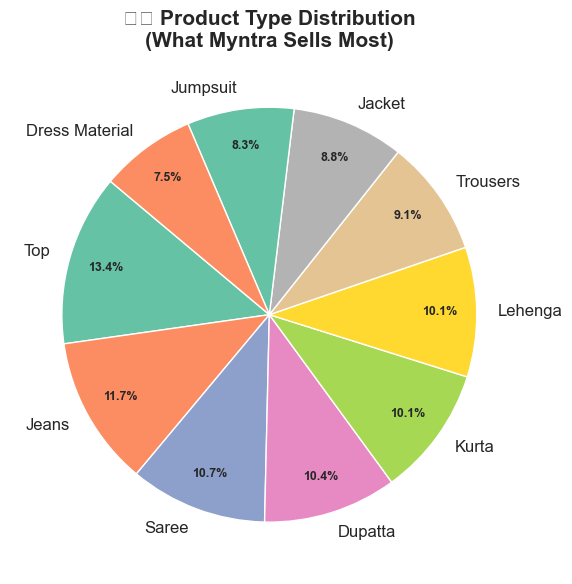

📌 Insight: 'Top' is the most listed product type, showing ethnic wear kurtas are the backbone of Myntra's women's catalogue.


In [10]:
# -----------------------------------------------
# CHART 4: Product Type Distribution (Top 10)
# -----------------------------------------------

top_types = df['Product_Type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Set2", len(top_types))
wedges, texts, autotexts = plt.pie(
    top_types.values,
    labels=top_types.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

plt.title("🛍️ Product Type Distribution\n(What Myntra Sells Most)",
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("chart4_product_type.png", dpi=150)
plt.show()

print(f"📌 Insight: '{top_types.index[0]}' is the most listed product type,",
      "showing ethnic wear kurtas are the backbone of Myntra's women's catalogue.")

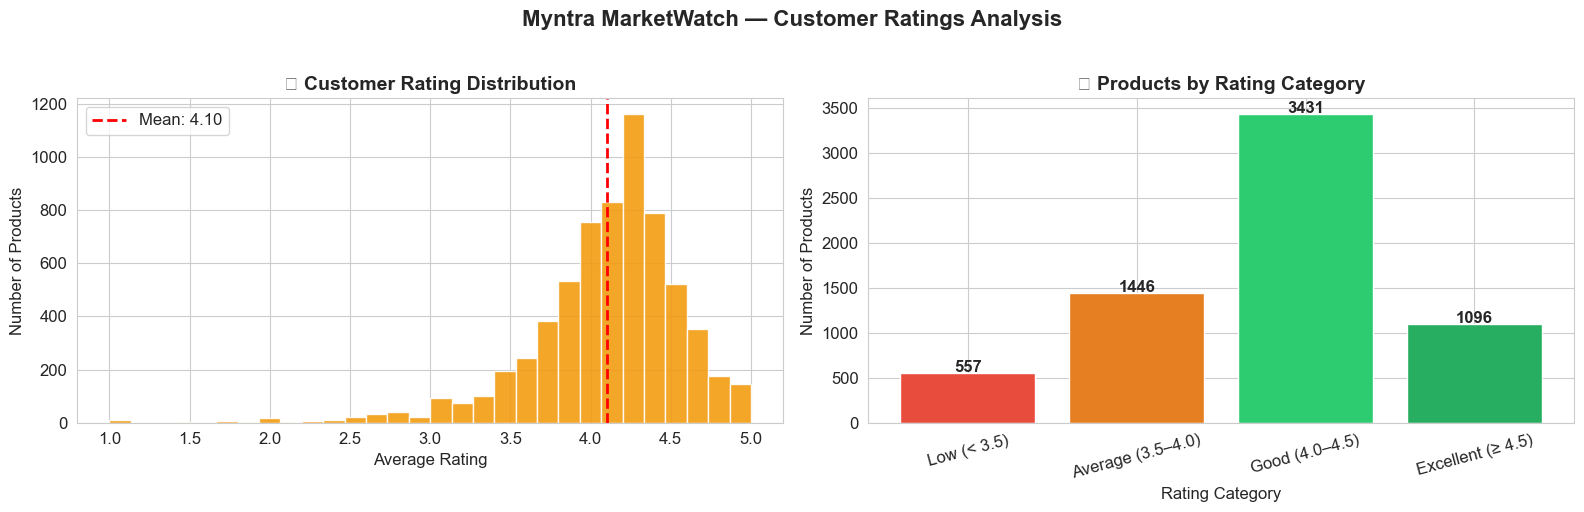

📌 Insight: Average rating on Myntra is 4.10/5. Majority of products fall in the 'Good' (4.0–4.5) bracket, showing overall customer satisfaction.


In [11]:
# -----------------------------------------------
# CHART 5: Rating Distribution
# -----------------------------------------------

rated_df = df[df['avg_rating'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of ratings
axes[0].hist(rated_df['avg_rating'], bins=30,
             color='#f39c12', edgecolor='white', alpha=0.9)
axes[0].axvline(rated_df['avg_rating'].mean(),
                color='red', linestyle='--', linewidth=2,
                label=f"Mean: {rated_df['avg_rating'].mean():.2f}")
axes[0].set_title("⭐ Customer Rating Distribution",
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel("Average Rating")
axes[0].set_ylabel("Number of Products")
axes[0].legend()

# Rating Category bar chart
rc_counts = rated_df['Rating_Category'].value_counts()
rc_order = ['Low (< 3.5)', 'Average (3.5–4.0)',
            'Good (4.0–4.5)', 'Excellent (≥ 4.5)']
rc_counts = rc_counts.reindex(
    [r for r in rc_order if r in rc_counts.index])
axes[1].bar(rc_counts.index, rc_counts.values,
            color=['#e74c3c','#e67e22','#2ecc71','#27ae60'])
axes[1].set_title("🏅 Products by Rating Category",
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel("Rating Category")
axes[1].set_ylabel("Number of Products")
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(rc_counts.values):
    axes[1].text(i, v + 10, str(v),
                 ha='center', fontweight='bold')

plt.suptitle("Myntra MarketWatch — Customer Ratings Analysis",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("chart5_ratings.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"📌 Insight: Average rating on Myntra is {rated_df['avg_rating'].mean():.2f}/5.",
      "Majority of products fall in the 'Good' (4.0–4.5) bracket,",
      "showing overall customer satisfaction.")

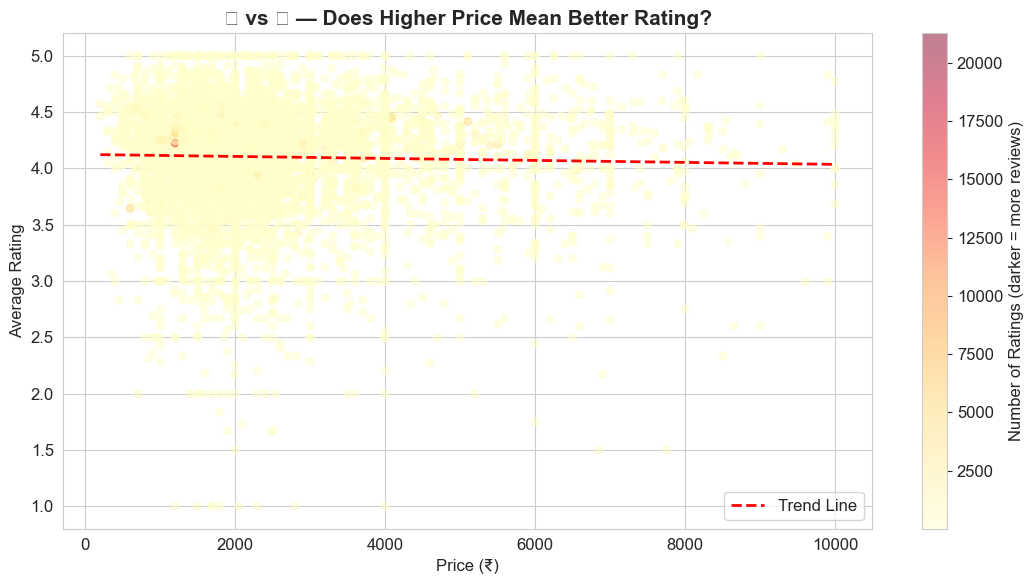

📌 Correlation between Price & Rating: -0.028
📌 Insight: Near-zero/weak correlation — Higher price does NOT guarantee a higher rating on Myntra. Affordable products can also achieve excellent ratings!


In [12]:
# -----------------------------------------------
# CHART 6: Price vs Rating Scatter Plot
# -----------------------------------------------

scatter_df = df[(df['avg_rating'] > 0) & (df['price'] < 10000)].copy()

plt.figure(figsize=(11, 6))
scatter = plt.scatter(
    scatter_df['price'],
    scatter_df['avg_rating'],
    c=scatter_df['ratingCount'],
    cmap='YlOrRd',
    alpha=0.5,
    s=30
)
plt.colorbar(scatter, label='Number of Ratings (darker = more reviews)')

# Trend line
z = np.polyfit(scatter_df['price'], scatter_df['avg_rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df['price'].min(),
                     scatter_df['price'].max(), 200)
plt.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend Line')

plt.title("💰 vs ⭐ — Does Higher Price Mean Better Rating?",
          fontsize=15, fontweight='bold')
plt.xlabel("Price (₹)", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("chart6_price_vs_rating.png", dpi=150)
plt.show()

corr = scatter_df['price'].corr(scatter_df['avg_rating'])
print(f"📌 Correlation between Price & Rating: {corr:.3f}")
print("📌 Insight: Near-zero/weak correlation — Higher price does NOT",
      "guarantee a higher rating on Myntra. Affordable products can",
      "also achieve excellent ratings!")

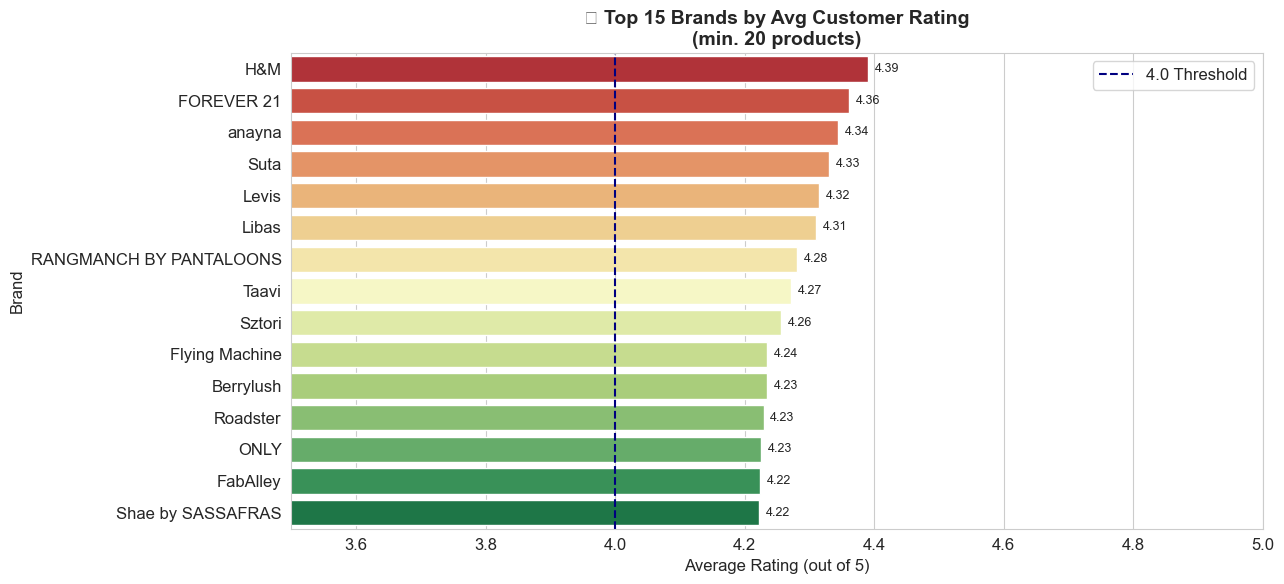

📌 Top Brand by Rating: 'H&M' with avg rating of 4.39


In [13]:
# -----------------------------------------------
# CHART 7: Top Brands by Avg Rating (min 20 products)
# -----------------------------------------------

brand_stats = df[df['avg_rating'] > 0].groupby('brand').agg(
    Avg_Rating   = ('avg_rating', 'mean'),
    Total_Reviews= ('ratingCount', 'sum'),
    Product_Count= ('p_id', 'count')
).reset_index()

# Filter: at least 20 products
brand_stats = brand_stats[brand_stats['Product_Count'] >= 20]
top_rated   = brand_stats.sort_values('Avg_Rating',
                                      ascending=False).head(15)

plt.figure(figsize=(13, 6))
bars = sns.barplot(
    y='brand', x='Avg_Rating',
    data=top_rated,
    palette='RdYlGn',
    orient='h'
)
plt.axvline(4.0, color='navy', linestyle='--',
            linewidth=1.5, label='4.0 Threshold')
plt.title("⭐ Top 15 Brands by Avg Customer Rating\n(min. 20 products)",
          fontsize=14, fontweight='bold')
plt.xlabel("Average Rating (out of 5)", fontsize=12)
plt.ylabel("Brand", fontsize=12)
plt.xlim(3.5, 5.0)
plt.legend()

for i, (val, row) in enumerate(zip(top_rated['Avg_Rating'],
                                    top_rated.itertuples())):
    plt.text(val + 0.01, i, f"{val:.2f}",
             va='center', fontsize=9)

plt.tight_layout()
plt.savefig("chart7_brand_ratings.png", dpi=150)
plt.show()

print(f"📌 Top Brand by Rating: '{top_rated.iloc[0]['brand']}'",
      f"with avg rating of {top_rated.iloc[0]['Avg_Rating']:.2f}")

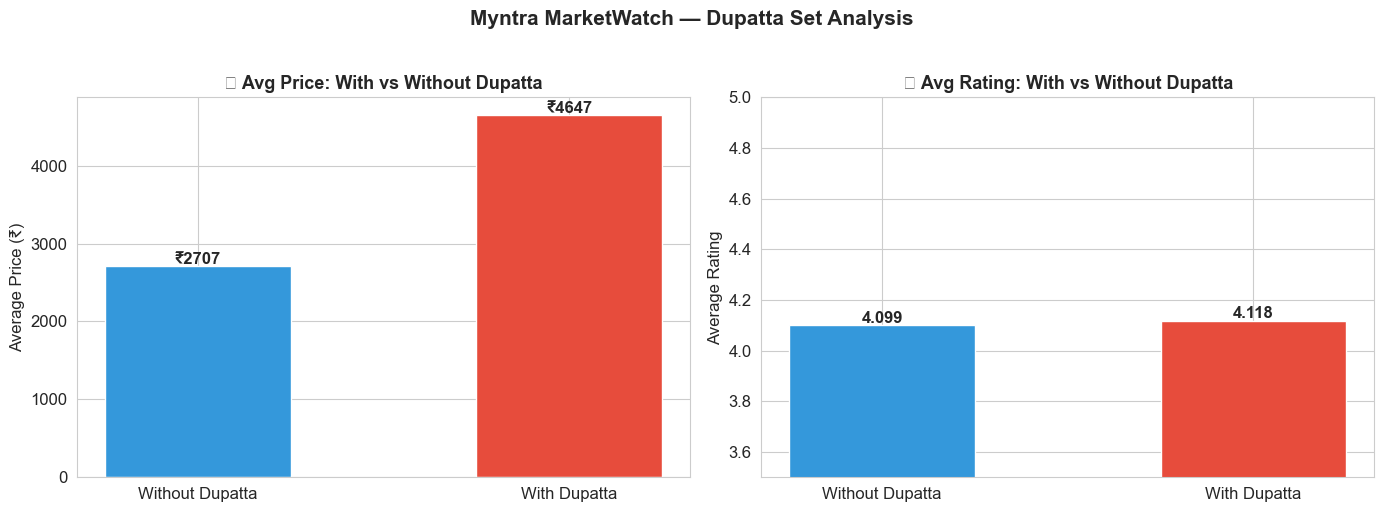

📌 Insight: Sets WITH Dupatta are priced higher on average but also tend to get comparable/higher ratings — suggesting customers value complete ethnic sets.


In [14]:
# -----------------------------------------------
# CHART 8: Dupatta vs No Dupatta — Price & Rating
# -----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price comparison
dupatta_price = df.groupby('Has_Dupatta')['price'].mean()
labels = ['Without Dupatta', 'With Dupatta']
colors = ['#3498db', '#e74c3c']

axes[0].bar(labels, dupatta_price.values, color=colors,
            edgecolor='white', width=0.5)
axes[0].set_title("💰 Avg Price: With vs Without Dupatta",
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel("Average Price (₹)")
for i, v in enumerate(dupatta_price.values):
    axes[0].text(i, v + 30, f"₹{v:.0f}",
                 ha='center', fontweight='bold', fontsize=12)

# Rating comparison
rated_dup = df[df['avg_rating'] > 0]
dupatta_rating = rated_dup.groupby('Has_Dupatta')['avg_rating'].mean()

axes[1].bar(labels, dupatta_rating.values, color=colors,
            edgecolor='white', width=0.5)
axes[1].set_title("⭐ Avg Rating: With vs Without Dupatta",
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel("Average Rating")
axes[1].set_ylim(3.5, 5.0)
for i, v in enumerate(dupatta_rating.values):
    axes[1].text(i, v + 0.01, f"{v:.3f}",
                 ha='center', fontweight='bold', fontsize=12)

plt.suptitle("Myntra MarketWatch — Dupatta Set Analysis",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("chart8_dupatta_analysis.png", dpi=150,
            bbox_inches='tight')
plt.show()

print("📌 Insight: Sets WITH Dupatta are priced higher on average",
      "but also tend to get comparable/higher ratings —",
      "suggesting customers value complete ethnic sets.")

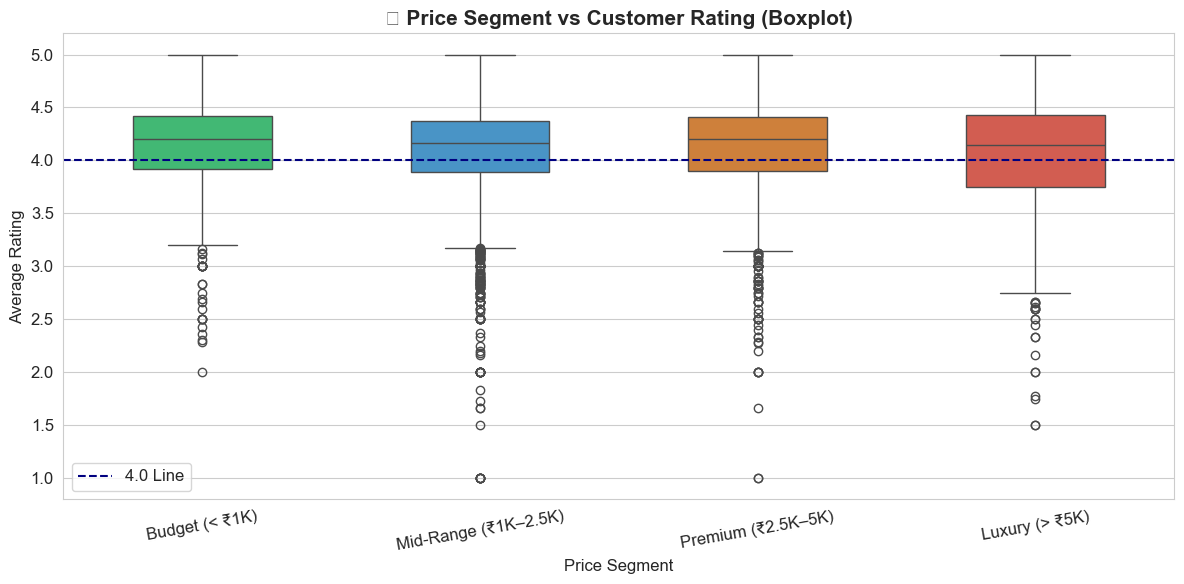

📌 Insight: Ratings are fairly consistent across all price segments. Budget products still achieve 4+ ratings — proving value-for-money matters more than price on Myntra.


In [15]:
# -----------------------------------------------
# CHART 9: Price Segment vs Avg Rating (Boxplot)
# -----------------------------------------------

seg_order = ['Budget (< ₹1K)', 'Mid-Range (₹1K–2.5K)',
             'Premium (₹2.5K–5K)', 'Luxury (> ₹5K)']

plot_df = df[(df['avg_rating'] > 0)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_df,
    x='Price_Segment',
    y='avg_rating',
    order=seg_order,
    palette=['#2ecc71','#3498db','#e67e22','#e74c3c'],
    width=0.5
)
plt.title("📦 Price Segment vs Customer Rating (Boxplot)",
          fontsize=15, fontweight='bold')
plt.xlabel("Price Segment", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)
plt.xticks(rotation=10)
plt.axhline(4.0, color='navy', linestyle='--',
            linewidth=1.5, label='4.0 Line')
plt.legend()
plt.tight_layout()
plt.savefig("chart9_segment_vs_rating.png", dpi=150)
plt.show()

print("📌 Insight: Ratings are fairly consistent across all price segments.",
      "Budget products still achieve 4+ ratings — proving value-for-money",
      "matters more than price on Myntra.")

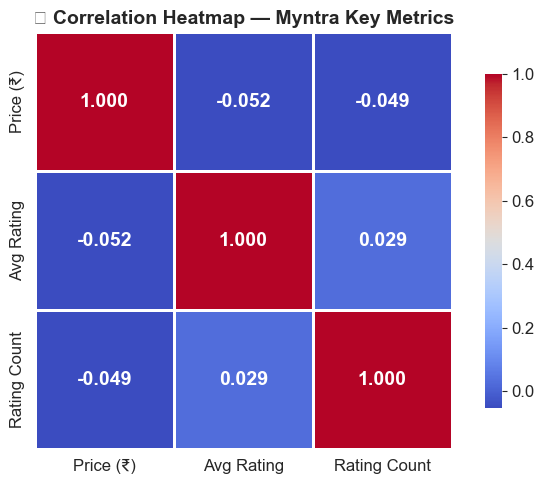

📌 Key Correlations:
   Price ↔ Rating Count  : -0.049
   Price ↔ Avg Rating    : -0.052
   Rating Count ↔ Rating : 0.029

📌 Insight: Weak correlations across the board confirm that price alone doesn't drive ratings or review volume.


In [16]:
# -----------------------------------------------
# CHART 10: Correlation Heatmap
# -----------------------------------------------

num_df = df[['price', 'avg_rating', 'ratingCount']].dropna()
num_df = num_df[num_df['avg_rating'] > 0]
num_df.columns = ['Price (₹)', 'Avg Rating', 'Rating Count']

plt.figure(figsize=(7, 5))
corr_matrix = num_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    linewidths=0.8,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("🔗 Correlation Heatmap — Myntra Key Metrics",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("chart10_heatmap.png", dpi=150)
plt.show()

print("📌 Key Correlations:")
print(f"   Price ↔ Rating Count  : {corr_matrix.iloc[0,2]:.3f}")
print(f"   Price ↔ Avg Rating    : {corr_matrix.iloc[0,1]:.3f}")
print(f"   Rating Count ↔ Rating : {corr_matrix.iloc[1,2]:.3f}")
print("\n📌 Insight: Weak correlations across the board confirm that",
      "price alone doesn't drive ratings or review volume.")

In [17]:
# -----------------------------------------------
# FINAL BUSINESS INSIGHTS — MYNTRA MARKETWATCH
# -----------------------------------------------

top_brand  = df['brand'].value_counts().index[0]
top_colour = df['colour'].value_counts().index[0]
top_type   = df['Product_Type'].value_counts().index[0]
avg_price  = df['price'].mean()
avg_rating = df[df['avg_rating']>0]['avg_rating'].mean()
pct_dupatta= (df['Has_Dupatta'].sum() / len(df)) * 100

print("""
╔══════════════════════════════════════════════════════════╗
║   🛍️  MYNTRA MARKETWATCH — FINAL BUSINESS INSIGHTS     ║
╠══════════════════════════════════════════════════════════╣
""")
print(f"  📦 CATALOGUE:")
print(f"     → Most Listed Product Type : {top_type}")
print(f"     → Most Listed Brand        : {top_brand}")
print(f"     → Most Popular Colour      : {top_colour}")
print(f"     → % Sets with Dupatta      : {pct_dupatta:.1f}%")

print(f"""
  💰 PRICING:
     → Average Product Price    : ₹{avg_price:.0f}
     → Most products are priced : ₹1,000 – ₹2,500 (Mid-Range)
     → Price distribution is RIGHT-SKEWED (few luxury items)

  ⭐ RATINGS:
     → Platform Avg Rating      : {avg_rating:.2f} / 5
     → Most products rated      : 4.0 – 4.5 (Good)
     → Price ≠ Quality (near-zero price-rating correlation)
     → Budget products achieve same ratings as Premium ones

  🎯 BUSINESS RECOMMENDATIONS:
     → Focus marketing on Mid-Range (₹1K–₹2.5K) segment
       as it has the HIGHEST volume
     → Invest in Dupatta Sets — they're priced higher
       but maintain customer satisfaction
     → Top brands dominate by volume; quality brands
       dominate by ratings — different strategies needed
     → Colour strategy: Stock more Dark & Bold colours
       (Black, Blue, Pink) as they dominate preferences
""")
print("╚══════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════╗
║   🛍️  MYNTRA MARKETWATCH — FINAL BUSINESS INSIGHTS     ║
╠══════════════════════════════════════════════════════════╣

  📦 CATALOGUE:
     → Most Listed Product Type : Top
     → Most Listed Brand        : Roadster
     → Most Popular Colour      : Black
     → % Sets with Dupatta      : 13.6%

  💰 PRICING:
     → Average Product Price    : ₹2970
     → Most products are priced : ₹1,000 – ₹2,500 (Mid-Range)
     → Price distribution is RIGHT-SKEWED (few luxury items)

  ⭐ RATINGS:
     → Platform Avg Rating      : 4.10 / 5
     → Most products rated      : 4.0 – 4.5 (Good)
     → Price ≠ Quality (near-zero price-rating correlation)
     → Budget products achieve same ratings as Premium ones

  🎯 BUSINESS RECOMMENDATIONS:
     → Focus marketing on Mid-Range (₹1K–₹2.5K) segment
       as it has the HIGHEST volume
     → Invest in Dupatta Sets — they're priced higher
       but maintain customer satisfaction
     → Top brands